# Protocol resting

## Import raw data to structured json data

Import raw data from /datasets/raw to structured json data in /datasets/restings. In my case I had .txt raw data from Elite HRV export Data.

In [3]:
from cardiolab.scripts.import_rr import import_all

## default output_dir is /datasets/resting

if __name__ == "__main__":
    import_all(output_dir = "cardiolab/datasets/resting")

Skipped (already exists): 2026-04-24 07-52-36.json
Skipped (already exists): 2026-04-25 07-58-25.json


## Pipeline Score, RMSSD, ... from json file

Print for all file json export with the date, and the differents stats from time domain (RMSSD, SDNN, PNN50 and mean HR)

In [4]:
from __future__ import annotations

import json
import glob

import numpy as np
import matplotlib.pyplot as plt

from cardiolab.signals.rr import RRSeries
from cardiolab.protocols.resting import resting_hrv, HRVFeatures
from cardiolab.analytics.baseline import Baseline
#from cardiolab.analytics.scoring import readiness_score_oura


path="cardiolab/datasets/resting/*.json"

files = sorted(glob.glob(path))
features_list = []

dates = []
rmssd_values = []
scores = []

baseline = Baseline()

for file in files:
    with open(file) as f:
        data = json.load(f)

    rr = RRSeries(data["rr_intervals"])
    result = resting_hrv(rr)

    features = HRVFeatures(
            date=data["date"],
            rmssd=result.rmssd,
            ln_rmssd=float(np.log(result.rmssd)) if result.rmssd > 0 else 0.0,
            sdnn=result.sdnn,
            pnn50=result.pnn50,
            mean_hr=result.mean_hr,
            vlf=result.vlf,
            lf=result.lf,
            hf=result.hf,
            lf_hf=result.lf_hf,
            hf_pct=result.hf_pct,
            lf_nu=result.lf_nu,
            hf_nu=result.hf_nu,
        )
    
    print({
            "date": features.date,
            "rmssd_value": features.rmssd,
            "sdnn_value": features.sdnn,
            "pnn50_value": features.pnn50,
            "mean_hr_value": features.mean_hr,
            "vlf": features.vlf,
            "lf": features.lf,
            "hf": features.hf,
            "lf_hf": features.lf_hf,
            "hf_pct": features.hf_pct,
            "lf_nu": features.lf_nu,
            "hf_nu": features.hf_nu
        })

    #features_list.append(features)

    

{'VLF': 0.0010620529485855213, 'LF': 0.001225676938465819, 'HF': 0.0003932548410857883, 'TP': 0.0026809847281371283, 'LF_HF': 3.116749777527693, 'LF_nu': 0.7570899243236133, 'HF_nu': 0.2429100756763867, 'HF_pct': 0.14668298441186567, 'LF_pct': 0.45717415903278036, 'LF_HF_sum': 0.0016189317795516072, 'LF_HF_over_TP': 0.603857143444646}
{'date': '2026-04-24 07-52-36', 'rmssd_value': 78.45952174034798, 'sdnn_value': 95.90436102471041, 'pnn50_value': 17.55485893416928, 'mean_hr_value': 57.896371525840784, 'vlf': 0.0010620529485855213, 'lf': 0.001225676938465819, 'hf': 0.0003932548410857883, 'lf_hf': 3.116749777527693, 'hf_pct': 0.14668298441186567, 'lf_nu': 0.7570899243236133, 'hf_nu': 0.2429100756763867}
{'VLF': 0.001763526835847757, 'LF': 0.0014656311826277632, 'HF': 0.0004967575985263126, 'TP': 0.0037259156170018327, 'LF_HF': 2.950395096070444, 'LF_nu': 0.7468607631184221, 'HF_nu': 0.25313923688157797, 'HF_pct': 0.1333249728629236, 'LF_pct': 0.3933613461184948, 'LF_HF_sum': 0.0019623887

In [8]:
from __future__ import annotations

import json
import glob
import numpy as np

from cardiolab.signals.rr import RRSeries
from cardiolab.protocols.resting import resting_hrv
from cardiolab.protocols.resting import HRVFeatures
from cardiolab.analytics.baseline import Baseline
from cardiolab.analytics.scoring import readiness_score_multi


def load_features_from_json(path="cardiolab/datasets/resting/*.json") -> list[HRVFeatures]:
    """
    FR :
    Charge les fichiers JSON du protocole resting et les convertit en HRVFeatures.

    EN :
    Loads resting protocol JSON files and converts them into HRVFeatures.
    """

    files = sorted(glob.glob(path))
    features_list = []

    for file in files:
        with open(file) as f:
            data = json.load(f)

        rr = RRSeries(data["rr_intervals"])
        result = resting_hrv(rr)

        features = HRVFeatures(
            date=data["date"],
            rmssd=result.rmssd,
            ln_rmssd=float(np.log(result.rmssd)) if result.rmssd > 0 else 0.0,
            sdnn=result.sdnn,
            pnn50=result.pnn50,
            mean_hr=result.mean_hr,
            vlf=result.vlf,
            lf=result.lf,
            hf=result.hf,
            lf_hf=result.lf_hf,
            hf_pct=result.hf_pct,
            lf_nu=result.lf_nu,
            hf_nu=result.hf_nu,
        )

        features_list.append(features)

    return features_list

def compute_scores(features_list: list[HRVFeatures], baseline: Baseline):
    """
    FR :
    Calcule et assigne le score à chaque feature.

    EN :
    Computes and assigns score to each feature.
    """

    for f in features_list:
        f.score = readiness_score_multi(f, baseline)


def display_results(features_list: list[HRVFeatures], baseline: Baseline):
    """
    FR :
    Affiche les résultats complets.

    EN :
    Displays full results.
    """

    print("\n===== DAILY METRICS =====\n")

    for f in features_list:
        print(f"Date: {f.date}")
        print(f"RMSSD: {f.rmssd:.2f}")
        print(f"HR: {f.mean_hr:.2f}")
        print(f"HF: {f.hf:.2f}")
        print(f"Score: {f.score:.2f}")
        print("-" * 30)

    print("\n===== BASELINE =====\n")
    print("Mean RMSSD:", baseline.mean_rmssd())
    print("Median RMSSD:", baseline.median_rmssd())
    print("Mean HR:", baseline.mean_hr())


def run():
    """
    FR :
    Pipeline complet :
    - lecture JSON
    - calcul features
    - construction baseline
    - affichage

    EN :
    Full pipeline:
    - load JSON
    - compute features
    - build baseline
    - display results
    """

    # 1. Load features
    features_list = load_features_from_json()

    if not features_list:
        print("No data found.")
        return

    # 2. Build baseline
    baseline = Baseline.from_features(features_list)

    # 3. Compute scores (ICI 👇)
    compute_scores(features_list, baseline)

    # 4. Display
    display_results(features_list, baseline)


if __name__ == "__main__":
    run()

{'VLF': 0.0010620529485855213, 'LF': 0.001225676938465819, 'HF': 0.0003932548410857883, 'TP': 0.0026809847281371283, 'LF_HF': 3.116749777527693, 'LF_nu': 0.7570899243236133, 'HF_nu': 0.2429100756763867, 'HF_pct': 0.14668298441186567, 'LF_pct': 0.45717415903278036, 'LF_HF_sum': 0.0016189317795516072, 'LF_HF_over_TP': 0.603857143444646}
{'VLF': 0.001763526835847757, 'LF': 0.0014656311826277632, 'HF': 0.0004967575985263126, 'TP': 0.0037259156170018327, 'LF_HF': 2.950395096070444, 'LF_nu': 0.7468607631184221, 'HF_nu': 0.25313923688157797, 'HF_pct': 0.1333249728629236, 'LF_pct': 0.3933613461184948, 'LF_HF_sum': 0.0019623887811540757, 'LF_HF_over_TP': 0.5266863189814184}

===== DAILY METRICS =====

Date: 2026-04-24 07-52-36
RMSSD: 78.46
HR: 57.90
HF: 0.00
Score: 52.43
------------------------------
Date: 2026-04-25 07-58-25
RMSSD: 51.79
HR: 52.23
HF: 0.00
Score: 42.53
------------------------------

===== BASELINE =====

Mean RMSSD: 65.12303105139996
Median RMSSD: 65.12303105139996
Mean HR: 

| Score  | Interprétation     |
| ------ | ------------------ |
| 80–100 | très bien récupéré |
| 60–80  | ok                 |
| 40–60  | fatigue modérée    |
| 20–40  | fatigué            |
| <20    | surcharge          |

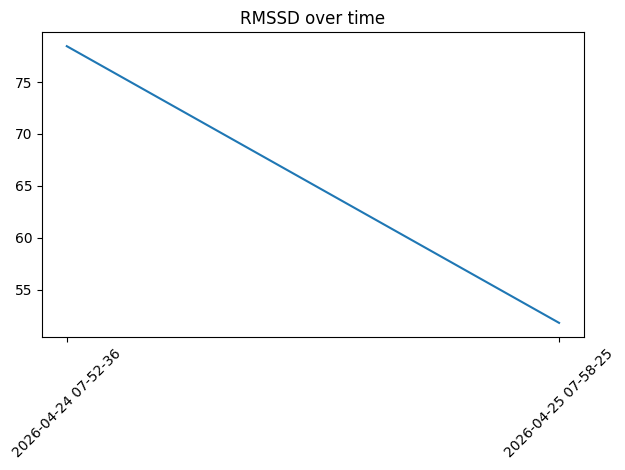

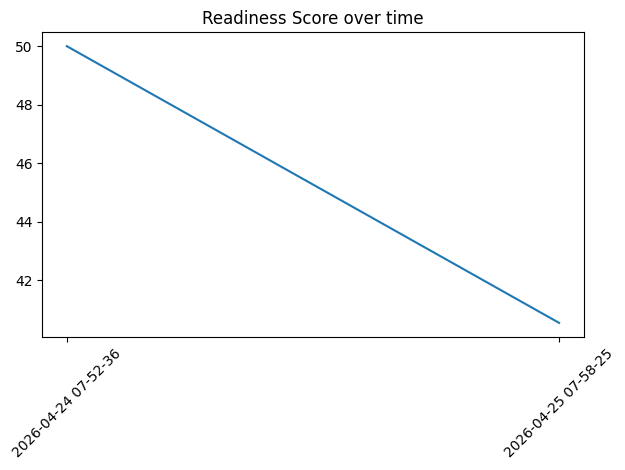

In [ ]:
from cardiolab.visualization.plot import plot_resting_evolution

plot_resting_evolution(path="cardiolab/datasets/resting/*.json")